<a href="https://colab.research.google.com/github/VishalK720/vishalcset343/blob/main/lab_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, f_oneway, ttest_ind

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif

import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

# Plotting style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


In [3]:
# Load the Pima Indians Diabetes Dataset

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (768, 9)


In [4]:
# Display first 10 records

df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.600,0.627,50,1
1,1,85,66,29,0,26.600,0.351,31,0
2,8,183,64,0,0,23.300,0.672,32,1
3,1,89,66,23,94,28.100,0.167,21,0
4,0,137,40,35,168,43.100,2.288,33,1
5,5,116,74,0,0,25.600,0.201,30,0
6,3,78,50,32,88,31.000,0.248,26,1
7,10,115,0,0,0,35.300,0.134,29,0
8,2,197,70,45,543,30.500,0.158,53,1
9,8,125,96,0,0,0.000,0.232,54,1


In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 768
Number of columns: 9

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [7]:
# Generate descriptive statistics

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000,768.000
mean,3.845,120.895,69.105,20.536,79.799,31.993,0.472,33.241,0.349
std,3.370,31.973,19.356,15.952,115.244,7.884,0.331,11.760,0.477
min,0.000,0.000,0.000,0.000,0.000,0.000,0.078,21.000,0.000
25%,1.000,99.000,62.000,0.000,0.000,27.300,0.244,24.000,0.000
50%,3.000,117.000,72.000,23.000,30.500,32.000,0.372,29.000,0.000
75%,6.000,140.250,80.000,32.000,127.250,36.600,0.626,41.000,1.000
max,17.000,199.000,122.000,99.000,846.000,67.100,2.420,81.000,1.000


In [8]:
# Check conventional missing/null values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


## 2. Healthcare-Specific Data Cleaning

In this dataset, zero values in some clinical measurements are not physiologically plausible and are treated as missing values.

The following variables are affected:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

However, `Pregnancies = 0` is a valid value and should not be treated as missing.

In [9]:
# Clinical variables where zero represents an invalid/missing measurement

clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Count zero values before treatment
zero_counts = (df[clinical_columns] == 0).sum()

print("Zero values representing potentially missing/invalid clinical measurements:")
print(zero_counts)

Zero values representing potentially missing/invalid clinical measurements:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [10]:
# Create a copy so the original dataset remains unchanged

df_clean = df.copy()

# Replace clinically invalid zeros with NaN
df_clean[clinical_columns] = df_clean[clinical_columns].replace(0, np.nan)

print("Invalid zero values converted to NaN.")

Invalid zero values converted to NaN.


In [11]:
# Check missing values after converting invalid zeros

missing_after_zero_conversion = df_clean.isnull().sum()

print("Missing values after clinical-value validation:")
print(missing_after_zero_conversion)

Missing values after clinical-value validation:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [12]:
# Median imputation for clinical variables

imputer = SimpleImputer(strategy="median")

df_clean[clinical_columns] = imputer.fit_transform(
    df_clean[clinical_columns]
)

print("Median imputation completed.")
print("\nRemaining missing values:")
print(df_clean.isnull().sum())

Median imputation completed.

Remaining missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [13]:
# Compare descriptive statistics before and after cleaning

comparison = pd.DataFrame({
    "Original Mean": df[clinical_columns].mean(),
    "Cleaned Mean": df_clean[clinical_columns].mean(),
    "Original Median": df[clinical_columns].median(),
    "Cleaned Median": df_clean[clinical_columns].median()
})

comparison

,Original Mean,Cleaned Mean,Original Median,Cleaned Median
Glucose,120.895,121.656,117.000,117.000
BloodPressure,69.105,72.387,72.000,72.000
SkinThickness,20.536,29.108,23.000,29.000
Insulin,79.799,140.672,30.500,125.000
BMI,31.993,32.455,32.000,32.300


## 3. Exploratory Data Analysis (EDA)

We now examine the distribution of diabetes outcomes and important clinical variables.

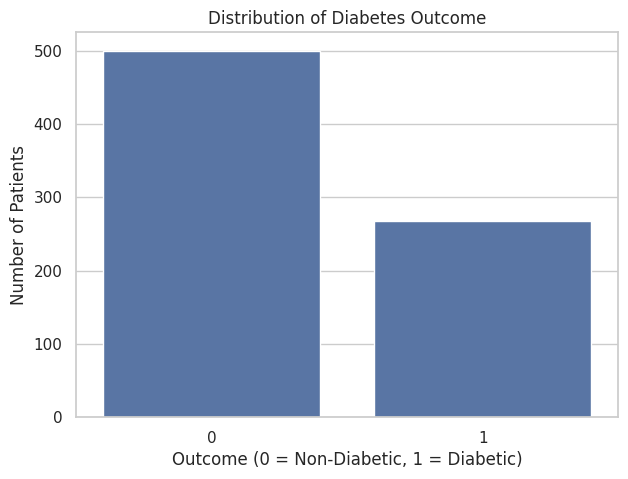

Outcome
0    500
1    268
Name: count, dtype: int64


In [14]:
# Outcome distribution

plt.figure(figsize=(7, 5))

sns.countplot(data=df_clean, x="Outcome")

plt.title("Distribution of Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("Number of Patients")

plt.show()

print(df_clean["Outcome"].value_counts())

In [15]:
# Calculate percentage distribution of outcomes

outcome_percentage = (
    df_clean["Outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Outcome percentage distribution:")
print(outcome_percentage)

Outcome percentage distribution:
Outcome
0   65.100
1   34.900
Name: proportion, dtype: float64


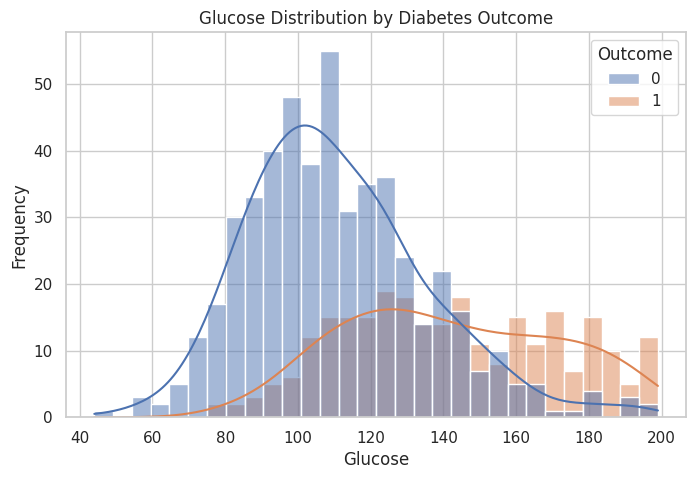

In [16]:
# Distribution of glucose levels

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="Glucose",
    hue="Outcome",
    kde=True,
    bins=30
)

plt.title("Glucose Distribution by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

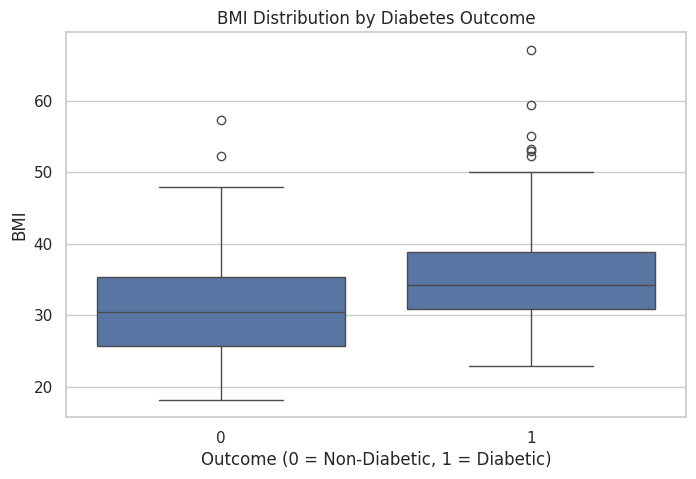

In [17]:
# BMI distribution by diabetes outcome

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="BMI"
)

plt.title("BMI Distribution by Diabetes Outcome")
plt.xlabel("Outcome (0 = Non-Diabetic, 1 = Diabetic)")
plt.ylabel("BMI")

plt.show()

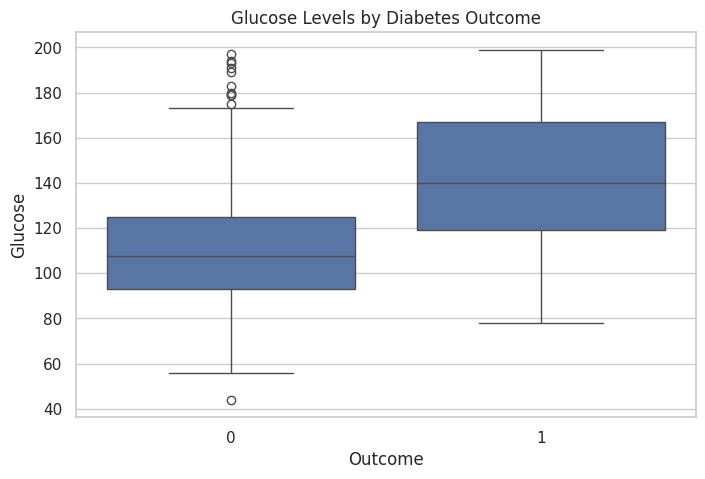

In [18]:
# Glucose distribution by outcome

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Outcome",
    y="Glucose"
)

plt.title("Glucose Levels by Diabetes Outcome")
plt.xlabel("Outcome")
plt.ylabel("Glucose")

plt.show()

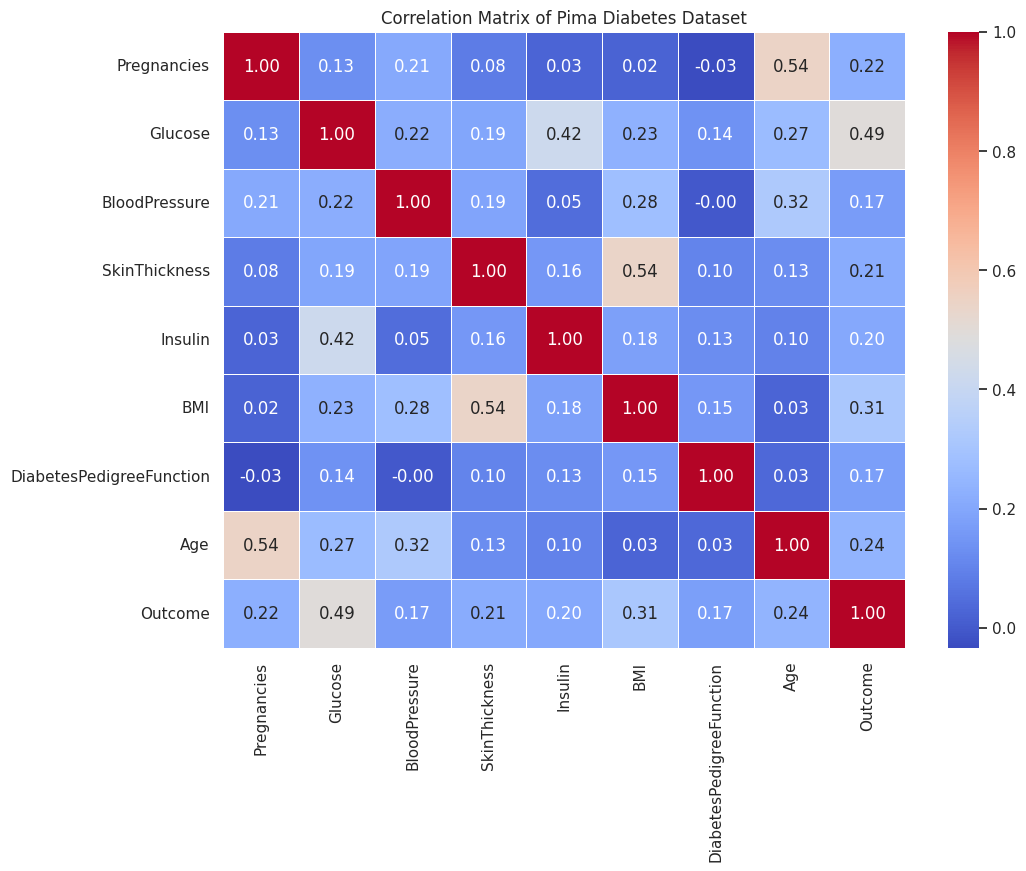

In [19]:
# Correlation matrix

plt.figure(figsize=(11, 8))

correlation_matrix = df_clean.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Pima Diabetes Dataset")

plt.show()

## 4. Hypothesis Testing

### Independent Two-Sample t-Test

We test whether the mean glucose level differs significantly between diabetic and non-diabetic patients.

**Null Hypothesis (H₀):**  
The mean glucose level is the same for diabetic and non-diabetic groups.

**Alternative Hypothesis (H₁):**  
The mean glucose level is different between the two groups.

Significance level: α = 0.05

In [20]:
# Separate glucose values by outcome

glucose_non_diabetic = df_clean.loc[
    df_clean["Outcome"] == 0, "Glucose"
]

glucose_diabetic = df_clean.loc[
    df_clean["Outcome"] == 1, "Glucose"
]

# Perform Welch's independent two-sample t-test
t_stat, p_value = ttest_ind(
    glucose_non_diabetic,
    glucose_diabetic,
    equal_var=False
)

print("Independent Two-Sample t-Test")
print("--------------------------------")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("There is statistically significant evidence that mean glucose differs between the two groups.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough statistical evidence that mean glucose differs between the two groups.")

Independent Two-Sample t-Test
--------------------------------
t-statistic: -14.8527
p-value: 0.000000

Decision: Reject H0
There is statistically significant evidence that mean glucose differs between the two groups.


## 5. Chi-Square Test

A Chi-square test of independence is used to determine whether two categorical variables are associated.

We investigate the relationship between **Age Group** and **Diabetes Outcome**.

**H₀:** Age Group and Diabetes Outcome are independent.

**H₁:** Age Group and Diabetes Outcome are associated.

Significance level: α = 0.05

In [21]:
# Create age groups for categorical analysis

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 40, 50, 100],
    labels=["21-30", "31-40", "41-50", "51+"],
    include_lowest=True
)

# Create contingency table

age_outcome_table = pd.crosstab(
    df_clean["AgeGroup"],
    df_clean["Outcome"]
)

print("Contingency Table:")
display(age_outcome_table)

# Perform Chi-square test

chi2, p_value, dof, expected = chi2_contingency(
    age_outcome_table
)

print("\nChi-Square Test Results")
print("----------------------")
print(f"Chi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nDecision: Reject H0")
    print("Age Group and Diabetes Outcome show a statistically significant association.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough evidence of an association between Age Group and Diabetes Outcome.")

Contingency Table:


Outcome,0,1
AgeGroup,,
21-30,327,90
31-40,81,76
41-50,49,64
51+,43,38



Chi-Square Test Results
----------------------
Chi-square statistic: 73.8089
Degrees of freedom: 3
p-value: 0.000000

Decision: Reject H0
Age Group and Diabetes Outcome show a statistically significant association.


## 6. One-Way ANOVA

One-way ANOVA is used to determine whether the mean of a numerical variable differs across three or more independent groups.

Here, we compare **mean Glucose levels across BMI categories**.

**H₀:** The mean glucose level is the same across all BMI groups.

**H₁:** At least one BMI group has a different mean glucose level.

Significance level: α = 0.05

In [22]:
# Create BMI categories

df_clean["BMICategory"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 18.5, 25, 30, 35, 100],
    labels=[
        "Underweight",
        "Normal",
        "Overweight",
        "Obesity_I",
        "Obesity_II+"
    ],
    include_lowest=True
)

# Display group sizes

print("BMI category counts:")
print(df_clean["BMICategory"].value_counts().sort_index())

BMI category counts:
BMICategory
Underweight      4
Normal         108
Overweight     180
Obesity_I      232
Obesity_II+    244
Name: count, dtype: int64


In [23]:
# Create groups for ANOVA

anova_groups = [
    group["Glucose"].values
    for _, group in df_clean.groupby(
        "BMICategory",
        observed=True
    )
]

# Perform one-way ANOVA

f_statistic, p_value = f_oneway(*anova_groups)

print("One-Way ANOVA Results")
print("---------------------")
print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("\nDecision: Reject H0")
    print("At least one BMI category has a significantly different mean glucose level.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough evidence that mean glucose differs across BMI categories.")

One-Way ANOVA Results
---------------------
F-statistic: 10.5862
p-value: 0.000000

Decision: Reject H0
At least one BMI category has a significantly different mean glucose level.


This satisfies the Feature Engineering requirement.

We'll create:

AgeGroup
BMICategory
Glucose_BMI_Interaction

The first two are categorical engineered features, while the interaction captures the combined relationship between glucose and BMI.

In [24]:
# Feature Engineering

df_engineered = df_clean.copy()

# Numerical interaction feature
df_engineered["Glucose_BMI_Interaction"] = (
    df_engineered["Glucose"] * df_engineered["BMI"]
)

# Display newly created features

df_engineered[
    [
        "Age",
        "AgeGroup",
        "BMI",
        "BMICategory",
        "Glucose",
        "Glucose_BMI_Interaction",
        "Outcome"
    ]
].head(10)

,Age,AgeGroup,BMI,BMICategory,Glucose,Glucose_BMI_Interaction,Outcome
0,50,41-50,33.600,Obesity_I,148.000,4972.800,1
1,31,31-40,26.600,Overweight,85.000,2261.000,0
2,32,31-40,23.300,Normal,183.000,4263.900,1
3,21,21-30,28.100,Overweight,89.000,2500.900,0
4,33,31-40,43.100,Obesity_II+,137.000,5904.700,1
5,30,21-30,25.600,Overweight,116.000,2969.600,0
6,26,21-30,31.000,Obesity_I,78.000,2418.000,1
7,29,21-30,35.300,Obesity_II+,115.000,4059.500,0
8,53,51+,30.500,Obesity_I,197.000,6008.500,1
9,54,51+,32.300,Obesity_I,125.000,4037.500,1


## 7. Feature Selection

Mutual Information is used to estimate the dependency between input features and the target variable.

Higher mutual information indicates a stronger dependency between a feature and the target.

In [25]:
# Select numerical features

feature_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Glucose_BMI_Interaction"
]

X = df_engineered[feature_columns]
y = df_engineered["Outcome"]

# Calculate mutual information

mi_scores = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": feature_columns,
    "Mutual Information": mi_scores
}).sort_values(
    by="Mutual Information",
    ascending=False
)

mi_results

,Feature,Mutual Information
8,Glucose_BMI_Interaction,0.135
1,Glucose,0.116
5,BMI,0.072
4,Insulin,0.061
7,Age,0.056
0,Pregnancies,0.027
3,SkinThickness,0.008
6,DiabetesPedigreeFunction,0.007
2,BloodPressure,0.007


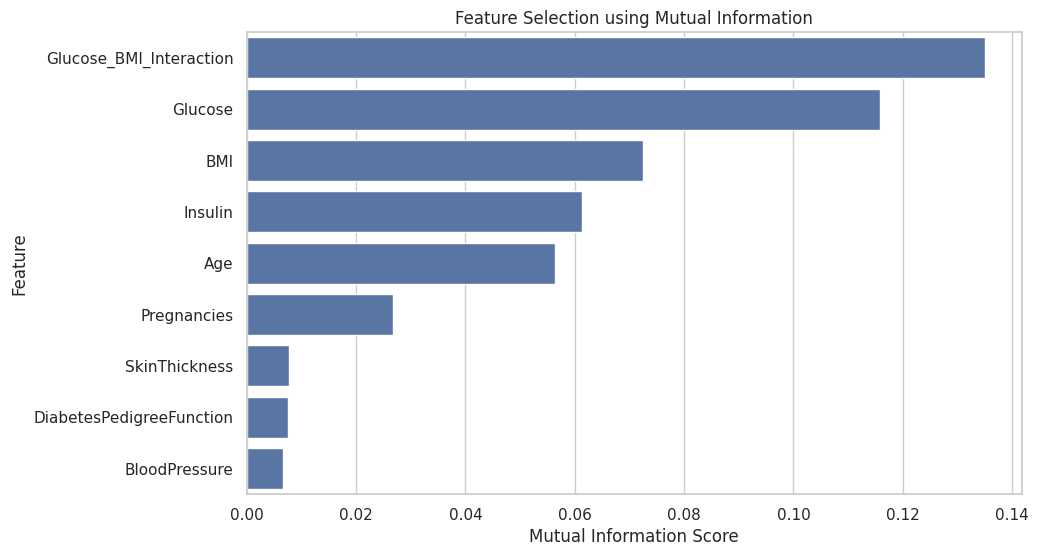

In [26]:
# Plot mutual information scores

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mi_results,
    x="Mutual Information",
    y="Feature"
)

plt.title("Feature Selection using Mutual Information")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")

plt.show()

In [27]:
# Select top 5 features based on mutual information

top_features = mi_results.head(5)["Feature"].tolist()

print("Top 5 selected features:")
for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")

Top 5 selected features:
1. Glucose_BMI_Interaction
2. Glucose
3. BMI
4. Insulin
5. Age


In [28]:
# Final numerical dataset for further analysis/modeling

selected_features = top_features + ["Outcome"]

final_dataset = df_engineered[selected_features].copy()

print("Final dataset shape:", final_dataset.shape)

display(final_dataset.head())

Final dataset shape: (768, 6)


,Glucose_BMI_Interaction,Glucose,BMI,Insulin,Age,Outcome
0,4972.800,148.000,33.600,125.000,50,1
1,2261.000,85.000,26.600,125.000,31,0
2,4263.900,183.000,23.300,125.000,32,1
3,2500.900,89.000,28.100,94.000,21,0
4,5904.700,137.000,43.100,168.000,33,1


In [29]:
# Final quality check

print("Final dataset information:")
print("--------------------------")

print("Shape:", final_dataset.shape)
print("Missing values:", final_dataset.isnull().sum().sum())
print("Duplicate rows:", final_dataset.duplicated().sum())

print("\nData types:")
print(final_dataset.dtypes)

Final dataset information:
--------------------------
Shape: (768, 6)
Missing values: 0
Duplicate rows: 0

Data types:
Glucose_BMI_Interaction    float64
Glucose                    float64
BMI                        float64
Insulin                    float64
Age                          int64
Outcome                      int64
dtype: object


## 8. Observations and Conclusion

### Observations

1. The Pima Indians Diabetes Dataset contains 768 patient records and 9 variables.
2. Conventional null values were absent, but zero values in several clinical measurements were identified as potentially invalid/missing values.
3. Zero values in Glucose, BloodPressure, SkinThickness, Insulin, and BMI were therefore treated as missing and replaced using median imputation.
4. Exploratory data analysis was performed using distributions, boxplots, and a correlation heatmap.
5. An independent two-sample t-test was used to compare glucose levels between diabetic and non-diabetic groups.
6. A Chi-square test was performed to investigate the association between age group and diabetes outcome.
7. One-way ANOVA was performed to compare glucose levels across BMI categories.
8. Additional features were created through feature engineering, including age groups, BMI categories, and a glucose-BMI interaction feature.
9. Mutual Information was used for feature selection and to rank the engineered numerical features according to their relationship with the diabetes outcome.

### Healthcare Data Considerations

Healthcare datasets require additional care because missing clinical measurements may be encoded using valid-looking numerical values such as zero. Therefore, domain knowledge must be considered before performing standard preprocessing.